In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd().parent
METADATA_DIR = PROJECT_ROOT / "metadata"
REPORT_DIR = PROJECT_ROOT / "reports" / "channel_audit"

REPORT_DIR.mkdir(parents=True, exist_ok=True)

PROJECT_ROOT

WindowsPath('E:/My_Github/epilepsy-eeg-hybrid-ai')

In [2]:
file_inventory = pd.read_csv(METADATA_DIR / "chbmit_file_inventory.csv")

channel_long = pd.read_csv(METADATA_DIR / "chbmit_channel_long.csv")

channel_counts = pd.read_csv(METADATA_DIR / "chbmit_channel_counts.csv")

presence_matrix = pd.read_csv(METADATA_DIR / "chbmit_channel_presence_matrix.csv")

signatures = pd.read_csv(METADATA_DIR / "chbmit_channel_signatures.csv")

target_summary = pd.read_csv(METADATA_DIR / "chbmit_target_channel_summary.csv")

problem_files = pd.read_csv(METADATA_DIR / "chbmit_problem_files.csv")

print("Files:", file_inventory.shape)
print("Channel rows:", channel_long.shape)
print("Presence matrix:", presence_matrix.shape)
print("Channel signatures:", signatures.shape)
print("Problem files:", problem_files.shape)

Files: (686, 19)
Channel rows: (17860, 9)
Presence matrix: (686, 99)
Channel signatures: (12, 8)
Problem files: (686, 12)


In [3]:
summary = {
    "edf_files": len(file_inventory),
    "patients_or_cases": file_inventory["patient_id"].nunique(),
    "minimum_channels": file_inventory["n_channels"].min(),
    "maximum_channels": file_inventory["n_channels"].max(),
    "modal_channels": file_inventory["n_channels"].mode().tolist(),
    "sampling_rates": sorted(
        file_inventory["sampling_rate_hz"].unique().tolist()
    ),
    "distinct_original_names": (
        channel_long["original_channel_name"].nunique()
    ),
    "distinct_normalized_names": (
        channel_long["normalized_channel_name"].nunique()
    ),
    "distinct_signatures": len(signatures),
}

pd.Series(summary)

edf_files                        686
patients_or_cases                 24
minimum_channels                  22
maximum_channels                  38
modal_channels                  [23]
sampling_rates               [256.0]
distinct_original_names           98
distinct_normalized_names         96
distinct_signatures               12
dtype: object

In [4]:
expected_channel_rows = int(file_inventory["n_channels"].sum())
observed_channel_rows = len(channel_long)

print("Expected:", expected_channel_rows)
print("Observed:", observed_channel_rows)
print("Match:", expected_channel_rows == observed_channel_rows)

assert expected_channel_rows == observed_channel_rows

Expected: 17860
Observed: 17860
Match: True


In [5]:
channel_count_distribution = (
    file_inventory["n_channels"]
    .value_counts()
    .sort_index()
    .rename_axis("n_channels")
    .reset_index(name="file_count")
)

channel_count_distribution

,n_channels,file_count
0,22,26
1,23,276
2,24,54
3,25,1
4,28,275
5,29,14
6,31,1
7,38,39


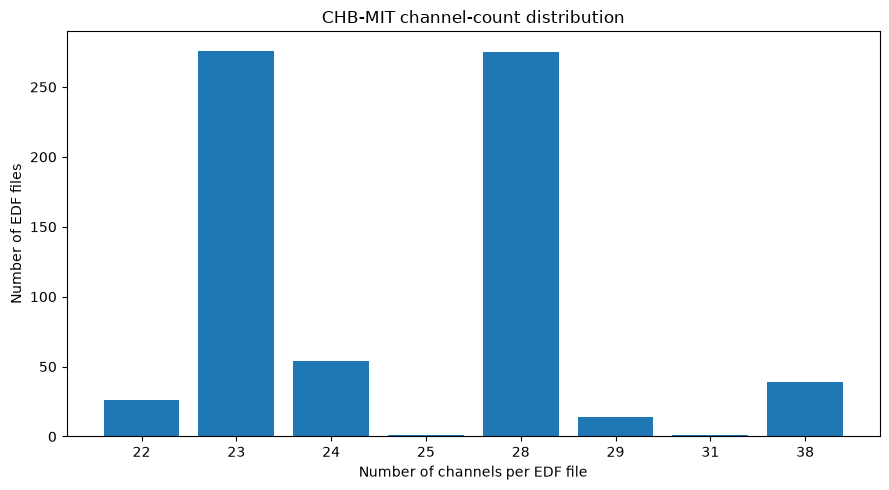

In [6]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.bar(
    channel_count_distribution["n_channels"].astype(str),
    channel_count_distribution["file_count"],
)

ax.set_xlabel("Number of channels per EDF file")
ax.set_ylabel("Number of EDF files")
ax.set_title("CHB-MIT channel-count distribution")

fig.tight_layout()
fig.savefig(
    REPORT_DIR / "channel_count_distribution.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

In [7]:
minimum_channels = file_inventory["n_channels"].min()
maximum_channels = file_inventory["n_channels"].max()

minimum_files = file_inventory.loc[
    file_inventory["n_channels"] == minimum_channels,
    [
        "patient_id",
        "recording_id",
        "n_channels",
        "normalized_channel_order",
    ],
]

maximum_files = file_inventory.loc[
    file_inventory["n_channels"] == maximum_channels,
    [
        "patient_id",
        "recording_id",
        "n_channels",
        "normalized_channel_order",
    ],
]

print("Minimum channel count:", minimum_channels)
display(minimum_files.head(20))

print("Maximum channel count:", maximum_channels)
display(maximum_files.head(20))

Minimum channel count: 22


,patient_id,recording_id,n_channels,normalized_channel_order
360,chb13,chb13_05,22,"[""FP1-F7"", ""F7-T7"", ""T7-P7"", ""P7-O1"", ""--0"", ""..."
361,chb13,chb13_06,22,"[""FP1-F7"", ""F7-T7"", ""T7-P7"", ""P7-O1"", ""--0"", ""..."
362,chb13,chb13_07,22,"[""FP1-F7"", ""F7-T7"", ""T7-P7"", ""P7-O1"", ""--0"", ""..."
363,chb13,chb13_08,22,"[""FP1-F7"", ""F7-T7"", ""T7-P7"", ""P7-O1"", ""--0"", ""..."
364,chb13,chb13_09,22,"[""FP1-F7"", ""F7-T7"", ""T7-P7"", ""P7-O1"", ""--0"", ""..."
365,chb13,chb13_10,22,"[""FP1-F7"", ""F7-T7"", ""T7-P7"", ""P7-O1"", ""--0"", ""..."
366,chb13,chb13_11,22,"[""FP1-F7"", ""F7-T7"", ""T7-P7"", ""P7-O1"", ""--0"", ""..."
367,chb13,chb13_12,22,"[""FP1-F7"", ""F7-T7"", ""T7-P7"", ""P7-O1"", ""--0"", ""..."
368,chb13,chb13_13,22,"[""FP1-F7"", ""F7-T7"", ""T7-P7"", ""P7-O1"", ""--0"", ""..."
369,chb13,chb13_14,22,"[""FP1-F7"", ""F7-T7"", ""T7-P7"", ""P7-O1"", ""--0"", ""..."


Maximum channel count: 38


,patient_id,recording_id,n_channels,normalized_channel_order
417,chb15,chb15_02,38,"[""FP1-F7"", ""F7-T7"", ""T7-P7"", ""P7-O1"", ""--0"", ""..."
418,chb15,chb15_03,38,"[""FP1-F7"", ""F7-T7"", ""T7-P7"", ""P7-O1"", ""--0"", ""..."
419,chb15,chb15_04,38,"[""FP1-F7"", ""F7-T7"", ""T7-P7"", ""P7-O1"", ""--0"", ""..."
420,chb15,chb15_05,38,"[""FP1-F7"", ""F7-T7"", ""T7-P7"", ""P7-O1"", ""--0"", ""..."
421,chb15,chb15_06,38,"[""FP1-F7"", ""F7-T7"", ""T7-P7"", ""P7-O1"", ""--0"", ""..."
422,chb15,chb15_07,38,"[""FP1-F7"", ""F7-T7"", ""T7-P7"", ""P7-O1"", ""--0"", ""..."
423,chb15,chb15_08,38,"[""FP1-F7"", ""F7-T7"", ""T7-P7"", ""P7-O1"", ""--0"", ""..."
424,chb15,chb15_09,38,"[""FP1-F7"", ""F7-T7"", ""T7-P7"", ""P7-O1"", ""--0"", ""..."
425,chb15,chb15_10,38,"[""FP1-F7"", ""F7-T7"", ""T7-P7"", ""P7-O1"", ""--0"", ""..."
426,chb15,chb15_11,38,"[""FP1-F7"", ""F7-T7"", ""T7-P7"", ""P7-O1"", ""--0"", ""..."


In [8]:
channels_95 = channel_counts.loc[
    channel_counts["file_coverage_fraction"] >= 0.95
].copy()

channels_95[
    [
        "channel_name",
        "file_count",
        "file_coverage_fraction",
        "patient_count",
        "patient_coverage_fraction",
    ]
]

,channel_name,file_count,file_coverage_fraction,patient_count,patient_coverage_fraction
0,C3-P3,683,0.995627,24,1.0
1,C4-P4,683,0.995627,24,1.0
2,CZ-PZ,683,0.995627,24,1.0
3,F3-C3,683,0.995627,24,1.0
4,F4-C4,683,0.995627,24,1.0
5,F7-T7,683,0.995627,24,1.0
6,F8-T8,683,0.995627,24,1.0
7,FP1-F3,683,0.995627,24,1.0
8,FP1-F7,683,0.995627,24,1.0
9,FP2-F4,683,0.995627,24,1.0


In [9]:
channels_95 = channels_95.assign(
    file_coverage_percent=(
        channels_95["file_coverage_fraction"] * 100
    ).round(2),
    patient_coverage_percent=(
        channels_95["patient_coverage_fraction"] * 100
    ).round(2),
)

channels_95[
    [
        "channel_name",
        "file_count",
        "file_coverage_percent",
        "patient_count",
        "patient_coverage_percent",
    ]
]

,channel_name,file_count,file_coverage_percent,patient_count,patient_coverage_percent
0,C3-P3,683,99.56,24,100.0
1,C4-P4,683,99.56,24,100.0
2,CZ-PZ,683,99.56,24,100.0
3,F3-C3,683,99.56,24,100.0
4,F4-C4,683,99.56,24,100.0
5,F7-T7,683,99.56,24,100.0
6,F8-T8,683,99.56,24,100.0
7,FP1-F3,683,99.56,24,100.0
8,FP1-F7,683,99.56,24,100.0
9,FP2-F4,683,99.56,24,100.0


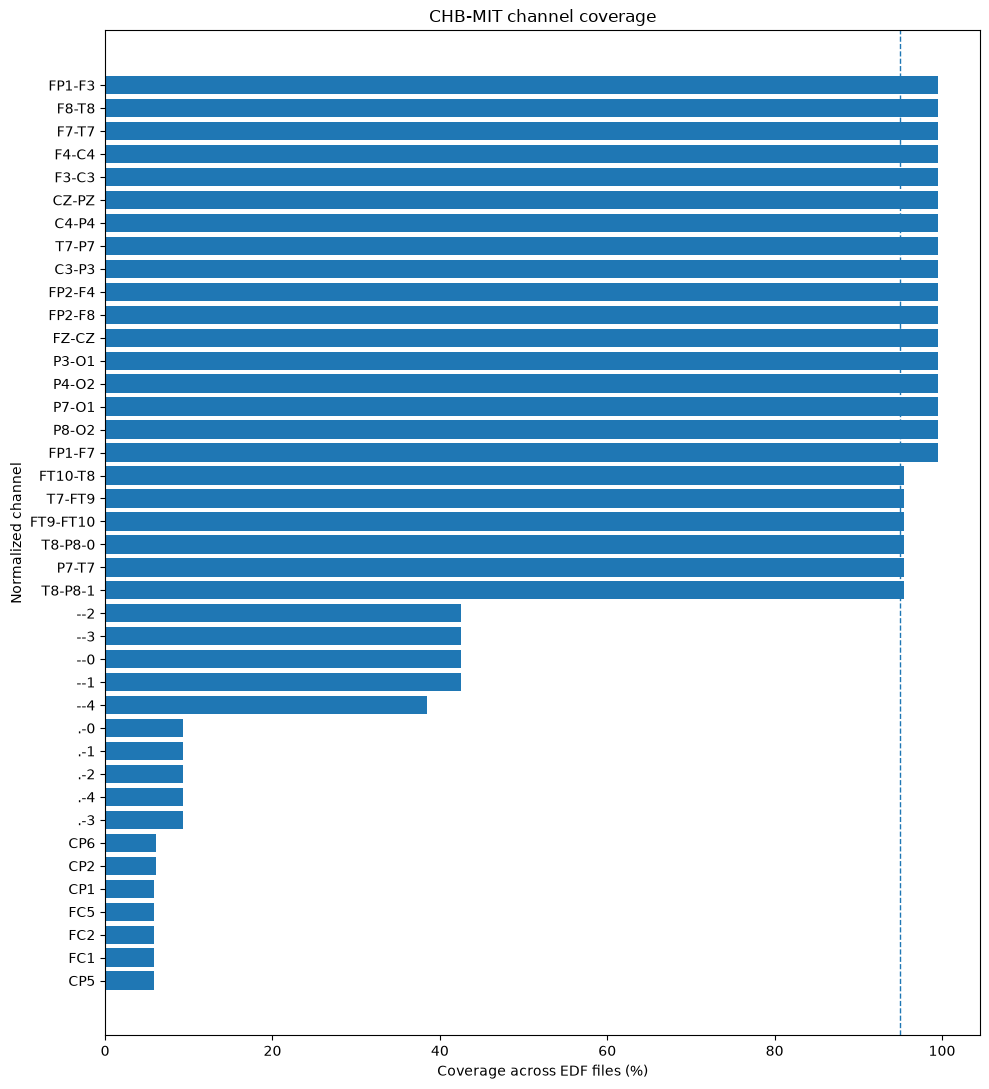

In [10]:
top_channels = channel_counts.head(40).sort_values(
    "file_coverage_fraction"
)

fig, ax = plt.subplots(figsize=(10, 11))

ax.barh(
    top_channels["channel_name"],
    top_channels["file_coverage_fraction"] * 100,
)

ax.axvline(
    95,
    linestyle="--",
    linewidth=1,
)

ax.set_xlabel("Coverage across EDF files (%)")
ax.set_ylabel("Normalized channel")
ax.set_title("CHB-MIT channel coverage")

fig.tight_layout()
fig.savefig(
    REPORT_DIR / "channel_coverage_top.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

In [11]:
patient_file_counts = (
    file_inventory.groupby("patient_id")
    .agg(
        file_count=("recording_id", "count"),
        minimum_channels=("n_channels", "min"),
        maximum_channels=("n_channels", "max"),
        distinct_signatures=(
            "unordered_channel_signature",
            "nunique",
        ),
    )
    .reset_index()
    .sort_values("patient_id")
)

patient_file_counts

,patient_id,file_count,minimum_channels,maximum_channels,distinct_signatures
0,chb01,42,23,23,1
1,chb02,36,23,23,1
2,chb03,38,23,23,1
3,chb04,42,23,24,2
4,chb05,39,23,23,1
5,chb06,18,23,23,1
6,chb07,19,23,23,1
7,chb08,20,23,23,1
8,chb09,19,23,24,2
9,chb10,25,23,23,1


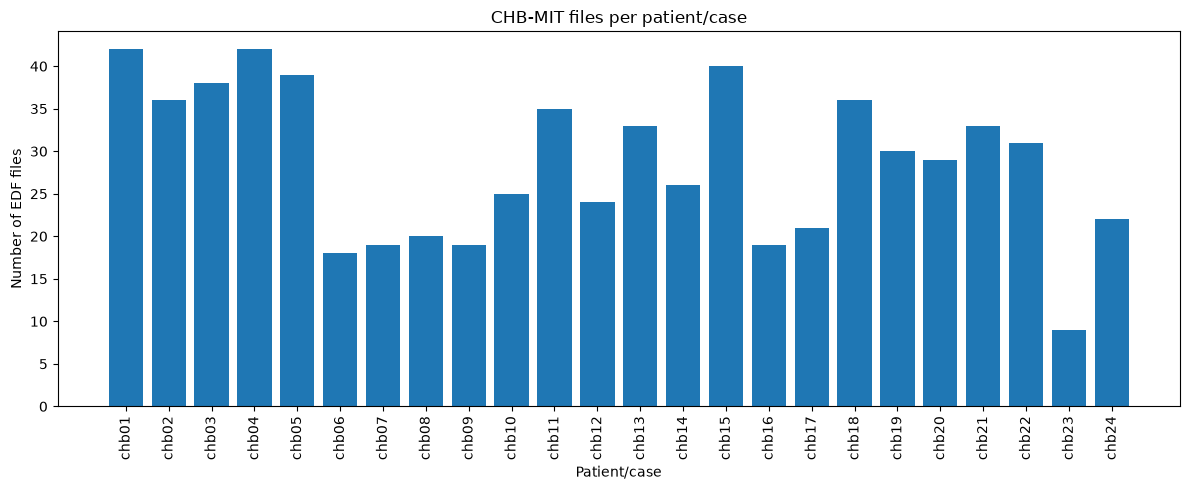

In [12]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.bar(
    patient_file_counts["patient_id"],
    patient_file_counts["file_count"],
)

ax.set_xlabel("Patient/case")
ax.set_ylabel("Number of EDF files")
ax.set_title("CHB-MIT files per patient/case")
ax.tick_params(axis="x", rotation=90)

fig.tight_layout()
fig.savefig(
    REPORT_DIR / "patient_file_counts.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

In [13]:
signatures[
    [
        "signature_id",
        "file_count",
        "patient_count",
        "minimum_channel_count",
        "maximum_channel_count",
        "example_patient",
        "example_recording",
    ]
].head(20)

,signature_id,file_count,patient_count,minimum_channel_count,maximum_channel_count,example_patient,example_recording
0,SIG-001,276,13,23,23,chb01,chb01_01
1,SIG-002,211,9,28,28,chb11,chb11_02
2,SIG-003,64,2,28,28,chb18,chb18_02
3,SIG-004,39,1,38,38,chb15,chb15_02
4,SIG-005,36,1,24,24,chb04,chb04_07
5,SIG-006,26,5,22,22,chb13,chb13_05
6,SIG-007,18,1,24,24,chb09,chb09_02
7,SIG-008,11,1,29,29,chb12,chb12_32
8,SIG-009,2,1,29,29,chb12,chb12_28
9,SIG-010,1,1,29,29,chb12,chb12_27


In [14]:
signature_id = signatures.iloc[0]["signature_id"]

signature_text = signatures.loc[
    signatures["signature_id"] == signature_id,
    "unordered_channel_signature",
].iloc[0]

signature_text.split("||")

['C3-P3',
 'C4-P4',
 'CZ-PZ',
 'F3-C3',
 'F4-C4',
 'F7-T7',
 'F8-T8',
 'FP1-F3',
 'FP1-F7',
 'FP2-F4',
 'FP2-F8',
 'FT10-T8',
 'FT9-FT10',
 'FZ-CZ',
 'P3-O1',
 'P4-O2',
 'P7-O1',
 'P7-T7',
 'P8-O2',
 'T7-FT9',
 'T7-P7',
 'T8-P8-0',
 'T8-P8-1']

In [15]:
ordering_variation = (
    file_inventory.groupby("unordered_channel_signature")
    .agg(
        file_count=("recording_id", "count"),
        distinct_orderings=(
            "ordered_channel_signature",
            "nunique",
        ),
    )
    .reset_index()
)

ordering_variation = ordering_variation.loc[
    ordering_variation["distinct_orderings"] > 1
]

print(
    "Channel sets with multiple channel orders:",
    len(ordering_variation),
)

ordering_variation.head()

Channel sets with multiple channel orders: 0


,unordered_channel_signature,file_count,distinct_orderings


In [16]:
suffix_channels = (
    channel_long.loc[
        channel_long["normalized_channel_name"].str.contains(
            r"-\d+$",
            regex=True,
            na=False,
        ),
        [
            "patient_id",
            "recording_id",
            "channel_index",
            "original_channel_name",
            "normalized_channel_name",
            "base_channel_name",
        ],
    ]
    .drop_duplicates()
    .sort_values(
        [
            "normalized_channel_name",
            "patient_id",
            "recording_id",
        ]
    )
)

suffix_channels.head(50)

,patient_id,recording_id,channel_index,original_channel_name,normalized_channel_name,base_channel_name
6935,chb11,chb11_02,4,--0,--0,-
6963,chb11,chb11_03,4,--0,--0,-
6991,chb11,chb11_04,4,--0,--0,-
7019,chb11,chb11_05,4,--0,--0,-
7047,chb11,chb11_06,4,--0,--0,-
7075,chb11,chb11_07,4,--0,--0,-
7103,chb11,chb11_08,4,--0,--0,-
7131,chb11,chb11_09,4,--0,--0,-
7159,chb11,chb11_10,4,--0,--0,-
7187,chb11,chb11_11,4,--0,--0,-


In [17]:
suffix_channels["normalized_channel_name"].value_counts()

normalized_channel_name
T8-P8-0    655
T8-P8-1    655
--0        292
--1        292
--2        292
--3        292
--4        264
.-0         64
.-1         64
.-2         64
.-3         64
.-4         64
--5         39
Name: count, dtype: int64

In [18]:
duplicate_files = file_inventory.loc[
    file_inventory["has_possible_suffix_duplicates"],
    [
        "patient_id",
        "recording_id",
        "relative_path",
        "n_channels",
        "possible_suffix_duplicate_bases",
        "normalized_channel_order",
    ],
]

duplicate_files.head(30)

,patient_id,recording_id,relative_path,n_channels,possible_suffix_duplicate_bases,normalized_channel_order
0,chb01,chb01_01,chb01/chb01_01.edf,23,T8-P8,"[""FP1-F7"", ""F7-T7"", ""T7-P7"", ""P7-O1"", ""FP1-F3""..."
1,chb01,chb01_02,chb01/chb01_02.edf,23,T8-P8,"[""FP1-F7"", ""F7-T7"", ""T7-P7"", ""P7-O1"", ""FP1-F3""..."
2,chb01,chb01_03,chb01/chb01_03.edf,23,T8-P8,"[""FP1-F7"", ""F7-T7"", ""T7-P7"", ""P7-O1"", ""FP1-F3""..."
3,chb01,chb01_04,chb01/chb01_04.edf,23,T8-P8,"[""FP1-F7"", ""F7-T7"", ""T7-P7"", ""P7-O1"", ""FP1-F3""..."
4,chb01,chb01_05,chb01/chb01_05.edf,23,T8-P8,"[""FP1-F7"", ""F7-T7"", ""T7-P7"", ""P7-O1"", ""FP1-F3""..."
5,chb01,chb01_06,chb01/chb01_06.edf,23,T8-P8,"[""FP1-F7"", ""F7-T7"", ""T7-P7"", ""P7-O1"", ""FP1-F3""..."
6,chb01,chb01_07,chb01/chb01_07.edf,23,T8-P8,"[""FP1-F7"", ""F7-T7"", ""T7-P7"", ""P7-O1"", ""FP1-F3""..."
7,chb01,chb01_08,chb01/chb01_08.edf,23,T8-P8,"[""FP1-F7"", ""F7-T7"", ""T7-P7"", ""P7-O1"", ""FP1-F3""..."
8,chb01,chb01_09,chb01/chb01_09.edf,23,T8-P8,"[""FP1-F7"", ""F7-T7"", ""T7-P7"", ""P7-O1"", ""FP1-F3""..."
9,chb01,chb01_10,chb01/chb01_10.edf,23,T8-P8,"[""FP1-F7"", ""F7-T7"", ""T7-P7"", ""P7-O1"", ""FP1-F3""..."


In [19]:
sampling_rate_distribution = (
    file_inventory["sampling_rate_hz"]
    .value_counts()
    .sort_index()
    .rename_axis("sampling_rate_hz")
    .reset_index(name="file_count")
)

sampling_rate_distribution

,sampling_rate_hz,file_count
0,256.0,686


In [20]:
target_summary

,channel_set_name,target_channel_count,complete_file_count,total_file_count,complete_file_fraction,covered_patient_count,total_patient_count
0,core_17,17,683,686,0.995627,24,24
1,extended_18,18,28,686,0.040816,6,24


In [21]:
target_summary.assign(
    complete_file_percent=(
        target_summary["complete_file_fraction"] * 100
    ).round(2)
)

,channel_set_name,target_channel_count,complete_file_count,total_file_count,complete_file_fraction,covered_patient_count,total_patient_count,complete_file_percent
0,core_17,17,683,686,0.995627,24,24,99.56
1,extended_18,18,28,686,0.040816,6,24,4.08


In [22]:
identifier_columns = [
    "patient_id",
    "recording_id",
    "relative_path",
]

channel_columns = [
    column
    for column in presence_matrix.columns
    if column not in identifier_columns
]

coverage_order = (
    presence_matrix[channel_columns]
    .sum(axis=0)
    .sort_values(ascending=False)
)

selected_channels = coverage_order.head(35).index.tolist()

heatmap_data = (
    presence_matrix
    .sort_values(["patient_id", "recording_id"])
    .set_index("recording_id")[selected_channels]
)

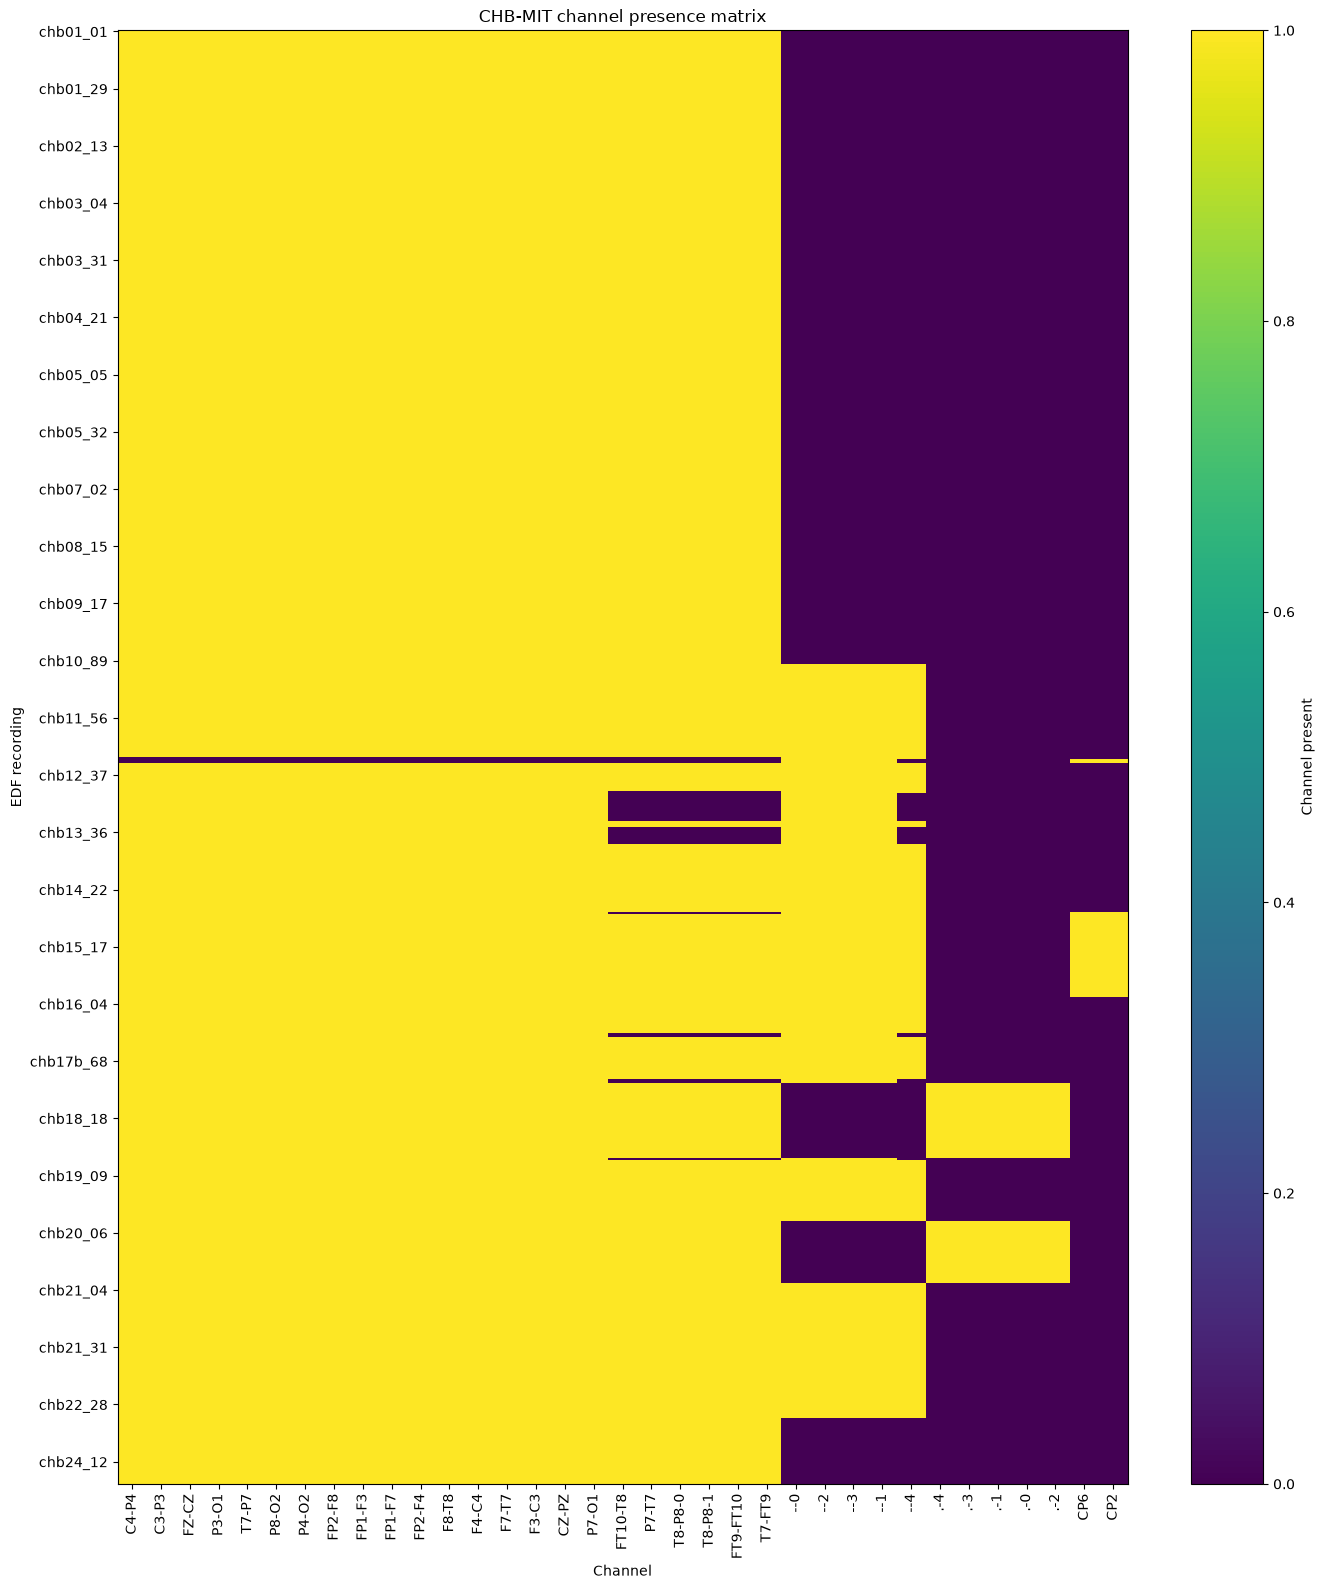

In [23]:
fig, ax = plt.subplots(figsize=(14, 16))

image = ax.imshow(
    heatmap_data.to_numpy(),
    aspect="auto",
    interpolation="nearest",
)

ax.set_xticks(np.arange(len(selected_channels)))
ax.set_xticklabels(
    selected_channels,
    rotation=90,
)

# برای جلوگیری از شلوغی فقط تعدادی از فایل‌ها برچسب می‌گیرند.
step = max(1, len(heatmap_data) // 25)
y_positions = np.arange(0, len(heatmap_data), step)

ax.set_yticks(y_positions)
ax.set_yticklabels(
    heatmap_data.index[y_positions]
)

ax.set_xlabel("Channel")
ax.set_ylabel("EDF recording")
ax.set_title("CHB-MIT channel presence matrix")

fig.colorbar(
    image,
    ax=ax,
    label="Channel present",
)

fig.tight_layout()
fig.savefig(
    REPORT_DIR / "channel_presence_heatmap.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

In [24]:
duplicate_comparison = pd.read_csv(
    METADATA_DIR / "chbmit_duplicate_channel_comparison.csv"
)

duplicate_comparison.sort_values(
    "pearson_correlation",
    ascending=False,
).head(30)

,patient_id,recording_id,relative_path,duplicate_base,first_channel,second_channel,samples_compared,exactly_identical,numerically_allclose,pearson_correlation,maximum_absolute_difference,root_mean_square_difference
4297,chb24,chb24_22,chb24/chb24_22.edf,T8-P8,T8-P8-0,T8-P8-1,76800,True,True,1.0,0.0,0.0
0,chb01,chb01_01,chb01/chb01_01.edf,T8-P8,T8-P8-0,T8-P8-1,76800,True,True,1.0,0.0,0.0
1,chb01,chb01_02,chb01/chb01_02.edf,T8-P8,T8-P8-0,T8-P8-1,76800,True,True,1.0,0.0,0.0
2,chb01,chb01_03,chb01/chb01_03.edf,T8-P8,T8-P8-0,T8-P8-1,76800,True,True,1.0,0.0,0.0
4281,chb24,chb24_06,chb24/chb24_06.edf,T8-P8,T8-P8-0,T8-P8-1,76800,True,True,1.0,0.0,0.0
4280,chb24,chb24_05,chb24/chb24_05.edf,T8-P8,T8-P8-0,T8-P8-1,76800,True,True,1.0,0.0,0.0
4279,chb24,chb24_04,chb24/chb24_04.edf,T8-P8,T8-P8-0,T8-P8-1,76800,True,True,1.0,0.0,0.0
4278,chb24,chb24_03,chb24/chb24_03.edf,T8-P8,T8-P8-0,T8-P8-1,76800,True,True,1.0,0.0,0.0
4277,chb24,chb24_02,chb24/chb24_02.edf,T8-P8,T8-P8-0,T8-P8-1,76800,True,True,1.0,0.0,0.0
4276,chb24,chb24_01,chb24/chb24_01.edf,T8-P8,T8-P8-0,T8-P8-1,76800,True,True,1.0,0.0,0.0
